In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime
import os
style.use('fast')
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score  
from statistics import mean

def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        plt.rc('xtick', labelsize=22)    
        plt.rc('ytick', labelsize=22)    
        plt.rcParams["font.family"] = "serif"
    
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [0, 1], 'k--',  lw=2.8)
        plt.plot(fpr, tpr, lw=2.8, color=color_ROC,label='Area = {:.3f}'.format(AUC_ROC))
        plt.fill_between(fpr, tpr,color=color_ROC, alpha=0.28)
        plt.xlabel('False positive rate',family="serif",fontsize = 26)
        plt.ylabel('True positive rate',family="serif",fontsize = 26)
        plt.title(f'ROC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/ROC_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [1, 0], 'k--',  lw=2.8)
        plt.plot(recall, precision, lw=2.8, color=color_PR,label='Area = {:.3f}'.format(AUC_PR))
        plt.fill_between(recall, precision,color=color_PR, alpha=0.28)
        plt.xlabel('Recall',family="serif",fontsize = 26)
        plt.ylabel('Precision',family="serif",fontsize = 26)
        plt.title(f'PRC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/PR_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
    
    return AUC_ROC, AUC_PR


In [6]:
nodes = 10
instance = 1
mean_importance_file_SWING = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t")
mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])

mean_importance_file_SWING.sort_values(by = ["regulator-target"])

,regulator-target,mean_importance
0,"('G1', 'G10')",0.003614
1,"('G1', 'G2')",0.016274
2,"('G1', 'G3')",0.041244
3,"('G1', 'G4')",0.119612
4,"('G1', 'G5')",0.036558
...,...,...
85,"('G9', 'G4')",0.020572
86,"('G9', 'G5')",0.021738
87,"('G9', 'G6')",0.075493
88,"('G9', 'G7')",0.029458


In [8]:
mean_importance_file_dynGENIE3

,Cause Gene,Effect Gene,mean_importance
0,G1,G10,0.057320
1,G1,G2,0.085705
2,G1,G3,0.204435
3,G1,G4,0.260921
4,G1,G5,0.180439
...,...,...,...
85,G9,G4,0.193006
86,G9,G5,0.210486
87,G9,G6,0.219150
88,G9,G7,0.096732


In [63]:
file_path_results = "Computing_Performance_2_in_degree/"
try:
    os.mkdir(file_path_results)
except OSError as error:
    print(f"Folder {file_path_results} already created.")

header_list_dynGENIE3_rand = ["Cause Gene", "Effect Gene", "mean_importance"]
header_list = ["Cause Gene", "Effect Gene", "Value"]
gold_standard = {}
Nodes = [10, 20, 50, 100]
step = 10

AUROC_value = {}
AUPRC_value = {}

for nodes in Nodes:
    
    AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"] = []
    AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes"] = []
    
    AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"] = []
    AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"] = []
    
    AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"] = []
    AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"] = []
    
    AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"] = []
    AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_rand"] = []
    
    AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"] = []
    AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"] = []
    
    AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"] = []
    AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_crand"] = []
    
    AUROC_value[f"AUROC_value_random_list_{nodes}genes"] = []
    AUPRC_value[f"AUPRC_value_random_list_{nodes}genes"] = []
    
    for instance in range(100):
        
        instance = instance + 1
        
        mean_importance_file_SWING = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t")
        mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
        
        mean_importance_file_SWING_rand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t")
        mean_importance_file_dynGENIE3_rand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list_dynGENIE3_rand).sort_values(by=["Cause Gene", "Effect Gene"])
        
        mean_importance_file_SWING_crand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t")
        mean_importance_file_dynGENIE3_crand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list_dynGENIE3_rand).sort_values(by=["Cause Gene", "Effect Gene"])
    
        rank_SWING = mean_importance_file_SWING["mean_importance"]
        rank_dynGENIE3 = mean_importance_file_dynGENIE3["mean_importance"]
        
        rank_SWING_rand = mean_importance_file_SWING_rand["mean_importance"]
        rank_dynGENIE3_rand = mean_importance_file_dynGENIE3_rand["mean_importance"]
        
        rank_SWING_crand = mean_importance_file_SWING_crand["mean_importance"]
        rank_dynGENIE3_crand = mean_importance_file_dynGENIE3_crand["mean_importance"]
        
        gold_standard = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Networks_in_out_degree_2_num_nodes_{nodes}/in_and_out_degree_2_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
        gold_standard = gold_standard.sort_values(by=["Cause Gene", "Effect Gene"])
        
        AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING, AUPRC_value_SWING = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_dynGENIE3_rand, AUPRC_value_dynGENIE3_rand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3_rand, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING_rand, AUPRC_value_SWING_rand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING_rand , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_dynGENIE3_crand, AUPRC_value_dynGENIE3_crand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3_crand, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING_crand, AUPRC_value_SWING_crand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING_crand , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_random, AUPRC_value_random = ROC_PR_AUC_Curves(gold_standard["Value"], np.random.rand(1,len(rank_SWING))[0].tolist() , nodes, "Nothing", f"Random Run {instance}", show_plot=False)
        
        #print(f"AUROC SWING value Run {instance}: ", AUROC_value_SWING)
        #print(f"AUPRC SWING value Run {instance}: ", AUPRC_value_SWING)
        #
        #print(f"AUROC dynGENIE3 value Run {instance}: ", AUROC_value_dynGENIE3)
        #print(f"AUPRC dynGENIE3 value Run {instance}: ", AUPRC_value_dynGENIE3)
        #
        #print(f"AUROC SWING rand value Run {instance}: ", AUROC_value_SWING_rand)
        #print(f"AUPRC SWING rand value Run {instance}: ", AUPRC_value_SWING_rand)
        #
        #print(f"AUROC dynGENIE3 rand value Run {instance}: ", AUROC_value_dynGENIE3_rand)
        #print(f"AUPRC dynGENIE3 rand value Run {instance}: ", AUPRC_value_dynGENIE3_rand)
        #
        #print(f"AUROC SWING crand value Run {instance}: ", AUROC_value_SWING_crand)
        #print(f"AUPRC SWING crand value Run {instance}: ", AUPRC_value_SWING_crand)
        #
        #print(f"AUROC dynGENIE3 crand value Run {instance}: ", AUROC_value_dynGENIE3_crand)
        #print(f"AUPRC dynGENIE3 crand value Run {instance}: ", AUPRC_value_dynGENIE3_crand)
        #
        #print(f"AUROC random value Run {instance}: ", AUROC_value_random)
        #print(f"AUPRC random value Run {instance}: ", AUROC_value_random)
        
        AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"].append(AUROC_value_SWING)
        AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"].append(AUPRC_value_SWING)
        
        AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"].append(AUROC_value_dynGENIE3)
        AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes"].append(AUPRC_value_dynGENIE3)
        
        AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"].append(AUROC_value_SWING_rand)
        AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_rand"].append(AUPRC_value_SWING_rand)
        
        AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"].append(AUROC_value_dynGENIE3_rand)
        AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"].append(AUPRC_value_dynGENIE3_rand)
        
        
        AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"].append(AUROC_value_SWING_crand)
        AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_crand"].append(AUPRC_value_SWING_crand)
        
        AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"].append(AUROC_value_dynGENIE3_crand)
        AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"].append(AUPRC_value_dynGENIE3_crand)
        
        
        AUROC_value[f"AUROC_value_random_list_{nodes}genes"].append(AUROC_value_random)
        AUPRC_value[f"AUPRC_value_random_list_{nodes}genes"].append(AUPRC_value_random)
        
        
    AUROC_file_SWING = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING.txt", "w")
    AUROC_file_dynGENIE3 = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3.txt", "w")
    AUROC_file_SWING_rand = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING_rand.txt", "w")
    AUROC_file_dynGENIE3_rand = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3_rand.txt", "w")
    AUROC_file_SWING_crand = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING_crand.txt", "w")
    AUROC_file_dynGENIE3_crand = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3_crand.txt", "w")
    AUROC_file_random = open(f"{file_path_results}/AUROC_results_{nodes}genes_random.txt", "w")
    
    AUPRC_file_SWING = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING.txt", "w")
    AUPRC_file_dynGENIE3 = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3.txt", "w")
    AUPRC_file_SWING_rand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING_rand.txt", "w")
    AUPRC_file_dynGENIE3_rand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3_rand.txt", "w")
    AUPRC_file_SWING_crand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING_crand.txt", "w")
    AUPRC_file_dynGENIE3_crand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3_crand.txt", "w")
    AUPRC_file_random = open(f"{file_path_results}/AUPRC_results_{nodes}genes_random.txt", "w")
    
    for element in AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"]:
        AUROC_file_SWING.write(str(element) + "\n")
    AUROC_file_SWING.close()
    
    for element in AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"]:
        AUROC_file_dynGENIE3.write(str(element) + "\n")
    AUROC_file_dynGENIE3.close()
    
    for element in AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"]:
        AUROC_file_SWING_rand.write(str(element) + "\n")
    AUROC_file_SWING_rand.close()
    
    for element in AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"]:
        AUROC_file_SWING_crand.write(str(element) + "\n")
    AUROC_file_SWING_crand.close()
    
    for element in AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]:
        AUROC_file_dynGENIE3_rand.write(str(element) + "\n")
    AUROC_file_dynGENIE3_rand.close()
    
    for element in AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]:
        AUROC_file_dynGENIE3_crand.write(str(element) + "\n")
    AUROC_file_dynGENIE3_crand.close()
    
    for element in AUROC_value[f"AUROC_value_random_list_{nodes}genes"]:
        AUROC_file_random.write(str(element) + "\n")
    AUROC_file_random.close()
    
    for element in AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"]:
        AUPRC_file_SWING.write(str(element) + "\n")
    AUPRC_file_SWING.close()
    
    for element in AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]:
        AUPRC_file_dynGENIE3.write(str(element) + "\n")
    AUPRC_file_dynGENIE3.close()
    
    for element in AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_rand"]:
        AUPRC_file_SWING_rand.write(str(element) + "\n")
    AUPRC_file_SWING_rand.close()
    
    for element in AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_crand"]:
        AUPRC_file_SWING_crand.write(str(element) + "\n")
    AUPRC_file_SWING_crand.close()
    
    for element in AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]:
        AUPRC_file_dynGENIE3_rand.write(str(element) + "\n")
    AUPRC_file_dynGENIE3_rand.close()
    
    for element in AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]:
        AUPRC_file_dynGENIE3_crand.write(str(element) + "\n")
    AUPRC_file_dynGENIE3_crand.close()
    
    for element in AUPRC_value[f"AUPRC_value_random_list_{nodes}genes"]:
        AUPRC_file_random.write(str(element) + "\n")
    AUPRC_file_random.close()
        

Folder Computing_Performance_2_in_degree/ already created.


# Bar plot: Averaging over all the ROC and PRC values

# AUROC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

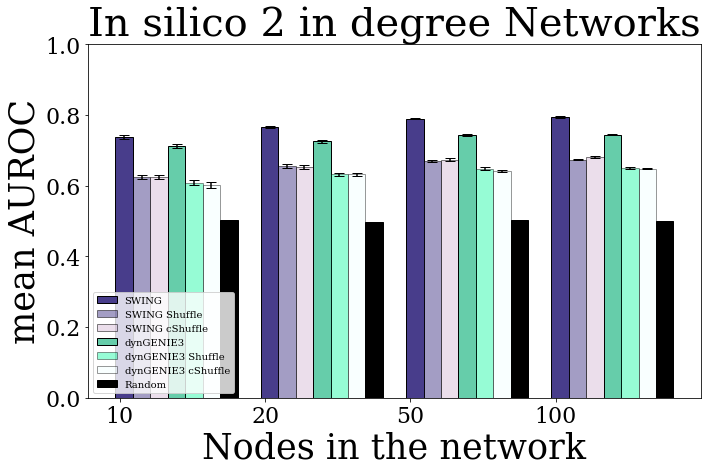

In [64]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [mean(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"]) for nodes in Nodes]
SWING_std = [np.std(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [mean(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"]) for nodes in Nodes]
SWING_rand_std = [np.std(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [mean(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"]) for nodes in Nodes]
SWING_crand_std = [np.std(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [mean(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"]) for nodes in Nodes]
dynGENIE3_std = [np.std(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [mean(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]) for nodes in Nodes]
dynGENIE3_rand_std = [np.std(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [mean(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]) for nodes in Nodes]
dynGENIE3_crand_std = [np.std(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [mean(AUROC_value[f"AUROC_value_random_list_{nodes}genes"]) for nodes in Nodes]
random_std = [np.std(AUROC_value[f"AUROC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 35)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 35)

plt.xticks([r + barWidth - 0.15 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In silico 2 in degree Networks", fontsize = 40)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2.png", bbox_inches="tight", dpi=100 )

# Overall ranking

In [70]:
(np.power(np.prod(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"]),1/100))/2

0.5179504177322791

In [ ]:
SWING = [AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"] for nodes in Nodes]


# AUPRC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

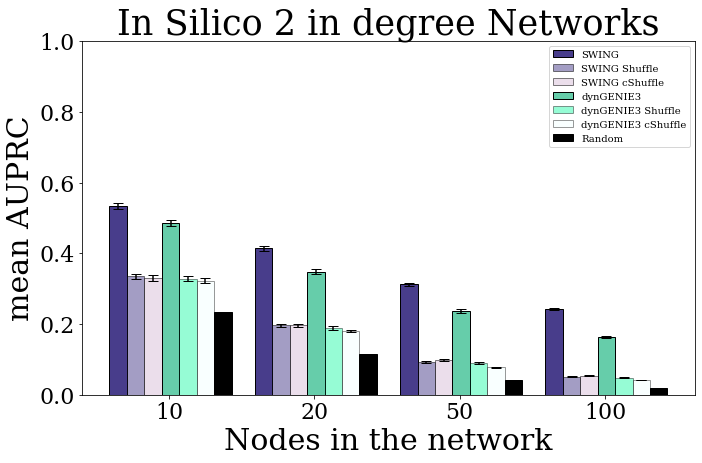

In [13]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [mean(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"]) for nodes in Nodes]
SWING_std = [np.std(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [mean(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_rand"]) for nodes in Nodes]
SWING_rand_std = [np.std(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [mean(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_crand"]) for nodes in Nodes]
SWING_crand_std = [np.std(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [mean(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]) for nodes in Nodes]
dynGENIE3_std = [np.std(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [mean(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]) for nodes in Nodes]
dynGENIE3_rand_std = [np.std(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [mean(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]) for nodes in Nodes]
dynGENIE3_crand_std = [np.std(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [mean(AUPRC_value[f"AUPRC_value_random_list_{nodes}genes"]) for nodes in Nodes]
random_std = [np.std(AUPRC_value[f"AUPRC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot
plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')

plt.ylabel('mean AUPRC', family = 'serif',fontsize = 30)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 30)
#FFD700
plt.xticks([r + barWidth + 0.23 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In Silico 2 in degree Networks", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2.png", bbox_inches="tight", dpi=100 )

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

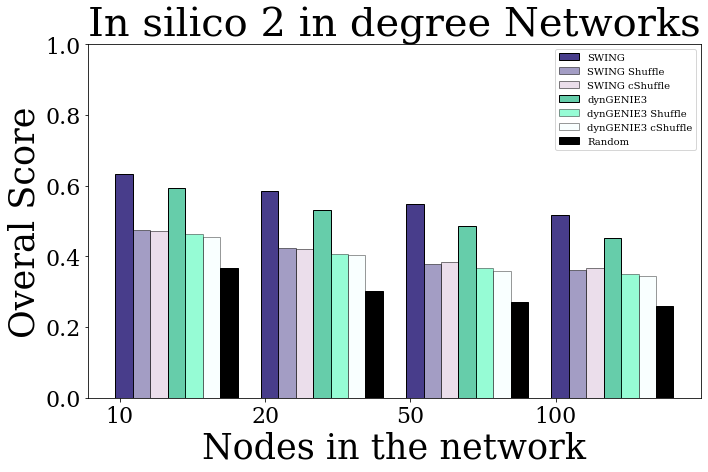

In [76]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [(np.power(np.prod(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes"]),1/100))/2 for nodes in Nodes]
#SWING_std = [np.std(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [(np.power(np.prod(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_rand"]),1/100))/2  for nodes in Nodes]
#SWING_rand_std = [np.std(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [(np.power(np.prod(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_SWING_list_{nodes}genes_crand"]),1/100))/2  for nodes in Nodes]
#SWING_crand_std = [np.std(AUROC_value[f"AUROC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [(np.power(np.prod(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]),1/100))/2  for nodes in Nodes]
#dynGENIE3_std = [np.std(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [(np.power(np.prod(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]),1/100))/2 for nodes in Nodes]
#dynGENIE3_rand_std = [np.std(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [(np.power(np.prod(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]),1/100))/2 for nodes in Nodes]
#dynGENIE3_crand_std = [np.std(AUROC_value[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [(np.power(np.prod(AUROC_value[f"AUROC_value_random_list_{nodes}genes"]),1/100) + np.power(np.prod(AUPRC_value[f"AUPRC_value_random_list_{nodes}genes"]),1/100))/2  for nodes in Nodes]
#random_std = [np.std(AUROC_value[f"AUROC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand,  color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand,  align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3,  color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand,  color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('Overal Score', family = 'serif',fontsize = 35)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 35)

plt.xticks([r + barWidth - 0.15 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In silico 2 in degree Networks", fontsize = 40)
plt.legend(prop={"size":10})
plt.ylim(0,1)

# Testing possible improvement

In [5]:
ranking = {}
Nodes = [10, 20, 50, 100]
Degree = [2]#,3,4]
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]

for nodes in Nodes:
    
    for degree in Degree:
        
        for instance in range(100):
            
            instance = instance + 1
            
            ranking[f"SWING_{degree}Degree_{nodes}Nodes_{instance}network"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["regulator-target"])
            ranking[f"SWING_{degree}Degree_{nodes}Nodes_{instance}network_rand"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t").sort_values(by=["regulator-target"])
            ranking[f"SWING_{degree}Degree_{nodes}Nodes_{instance}network_crand"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t").sort_values(by=["regulator-target"])
            
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network"] = pd.DataFrame()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_rand"] = pd.DataFrame()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_crand"] = pd.DataFrame()
            
            #genes = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["regulator-target"])["regulator-target"].values.tolist()
    
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network"]["Cause Gene"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])["Cause Gene"].values.tolist()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network"]["Effect Gene"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])["Effect Gene"].values.tolist()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network"]["mean_importance"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])["mean_importance"].values.tolist()
            
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_rand"]["Cause Gene"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])["Cause Gene"].values.tolist()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_rand"]["Effect Gene"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])["Effect Gene"].values.tolist()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_rand"]["mean_importance"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])["mean_importance"].values.tolist()
            
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_crand"]["Cause Gene"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])["Cause Gene"].values.tolist()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_crand"]["Effect Gene"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])["Effect Gene"].values.tolist()
            ranking[f"dynGENIE3_{degree}Degree_{nodes}Nodes_{instance}network_crand"]["mean_importance"] = pd.read_csv(f"networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])["mean_importance"].values.tolist()
        

In [7]:
ranking[f"SWING_2Degree_20Nodes_1network"]

,regulator-target,mean_importance
0,"('G1', 'G10')",0.005272
1,"('G1', 'G11')",0.069666
2,"('G1', 'G12')",0.006383
3,"('G1', 'G13')",0.003868
4,"('G1', 'G14')",0.001671
...,...,...
375,"('G9', 'G4')",0.022179
376,"('G9', 'G5')",0.084002
377,"('G9', 'G6')",0.009107
378,"('G9', 'G7')",0.022840


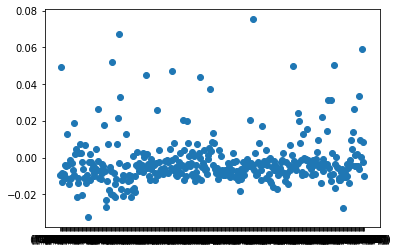

In [52]:
nodes = 20
new = ranking[f"SWING_2Degree_{nodes}Nodes_1network"]["mean_importance"]-ranking[f"SWING_2Degree_{nodes}Nodes_1network_rand"]["mean_importance"]

plt.plot(ranking[f"SWING_2Degree_{nodes}Nodes_1network"]["regulator-target"].values, new.values, 'o')


In [57]:
new_data = pd.DataFrame()
new_data['regulator-target'] = ranking[f"SWING_2Degree_{nodes}Nodes_1network"]["regulator-target"].values
new_data['mean_importance'] = new.values
new_data = new_data.sort_values(by = ['mean_importance'], ascending = False)
new_data[new_data['mean_importance']>0].sort_values(by =["regulator-target"])[0:20]

,regulator-target,mean_importance
1,"('G1', 'G11')",0.049329
9,"('G1', 'G19')",0.012798
17,"('G1', 'G8')",0.018783
19,"('G10', 'G1')",0.001872
20,"('G10', 'G11')",0.004772
24,"('G10', 'G15')",0.002400
25,"('G10', 'G16')",0.007235
26,"('G10', 'G17')",0.002277
31,"('G10', 'G3')",0.006901
38,"('G11', 'G1')",0.001979


In [56]:
gold_standard = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/2_in_degree_networks/networks_in_out_degree_2_num_nodes_{nodes}/Networks_in_out_degree_2_num_nodes_{nodes}/in_and_out_degree_2_num_nodes_{nodes}_case_1/goldstandard_signed_1_goldstandard.tsv", sep = '\t',names = header_list)
gold_standard[gold_standard['mean_importance']==1].sort_values(by =["Cause Gene","Effect Gene"])[0:12]

,Cause Gene,Effect Gene,mean_importance
0,G1,G11,1
1,G1,G19,1
15,G10,G13,1
14,G10,G4,1
3,G11,G16,1
2,G11,G8,1
35,G12,G18,1
34,G12,G7,1
25,G13,G12,1
24,G13,G16,1


In [117]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
data = pd.read_csv("C:/Users/ivana/OneDrive/Desktop/Internship New Folder/2_in_degree_networks/networks_in_out_degree_2_num_nodes_10/Networks_in_out_degree_2_num_nodes_10/in_and_out_degree_2_num_nodes_10_case_2/goldstandard_signed_2_dream4_timeseries.tsv", sep = '\t')[0:21].sample(frac=1, axis =1)
gold_standard = pd.read_csv("C:/Users/ivana/OneDrive/Desktop/Internship New Folder/2_in_degree_networks/networks_in_out_degree_2_num_nodes_100/Networks_in_out_degree_2_num_nodes_100/in_and_out_degree_2_num_nodes_100_case_1/goldstandard_signed_1_goldstandard.tsv", sep = '\t',names = header_list)

lista_genes = []

for i in range(len(gold_standard)):
    if gold_standard["mean_importance"].loc[i] == 1:
        lista_genes.append(f"('{gold_standard['Cause Gene'].iloc[i]}', '{gold_standard['Effect Gene'].iloc[i]}')")
            


In [118]:
lista_genes[0]

"('G1', 'G10')"

In [112]:
ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network"]

,regulator-target,mean_importance
0,"('G1', 'G10')",0.003627
1,"('G1', 'G100')",0.009012
2,"('G1', 'G11')",0.003644
3,"('G1', 'G12')",0.009951
4,"('G1', 'G13')",0.005897
...,...,...
9895,"('G99', 'G94')",0.005862
9896,"('G99', 'G95')",0.027400
9897,"('G99', 'G96')",0.010801
9898,"('G99', 'G97')",0.010783


In [137]:
ranking_real = []
genes_real = []

for rank in range(len(ranking[f"SWING_{degree}Degree_100Nodes_2network"])):
    for i in range(len(lista_genes)):
        if ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network"]['regulator-target'].iloc[rank] == lista_genes[i]:
            ranking_real.append(ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network"]['mean_importance'].iloc[rank])
        else:
            ranking_real.append(0)
        genes_real.append(ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network"]['regulator-target'].iloc[rank])

ranking_real_data_frame = pd.DataFrame()
ranking_real_data_frame["regulator-target"] = genes_real
ranking_real_data_frame["mean_importance"] = ranking_real
ranking_real_data_frame.sort_values(by =["regulator-target"])

In [138]:
ranking_real_data_frame = pd.DataFrame()
ranking_real_data_frame["regulator-target"] = genes_real
ranking_real_data_frame["mean_importance"] = ranking_real
ranking_real_data_frame.sort_values(by =["regulator-target"])

,regulator-target,mean_importance
0,"('G1', 'G10')",0.003627
127,"('G1', 'G10')",0.000000
128,"('G1', 'G10')",0.000000
129,"('G1', 'G10')",0.000000
130,"('G1', 'G10')",0.000000
...,...,...
1979869,"('G99', 'G98')",0.000000
1979870,"('G99', 'G98')",0.000000
1979871,"('G99', 'G98')",0.000000
1979861,"('G99', 'G98')",0.000000


In [139]:
ranking_real_rand = []
genes_real_rand = []

for rank in range(len(ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network_rand"])):
    for i in range(len(lista_genes)):
        if ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network_rand"]['regulator-target'].iloc[rank] == lista_genes[i]:
            ranking_real_rand.append(ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network_rand"]['mean_importance'].iloc[rank])
        else:
            ranking_real_rand.append(0)
        genes_real_rand.append(ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network_rand"]['regulator-target'].iloc[rank])
        

In [140]:
ranking_real_data_frame_rand = pd.DataFrame()
ranking_real_data_frame_rand["regulator-target"] = genes_real_rand
ranking_real_data_frame_rand["mean_importance"] = ranking_real_rand
ranking_real_data_frame_rand.sort_values(by =["regulator-target"])

,regulator-target,mean_importance
0,"('G1', 'G10')",0.011116
127,"('G1', 'G10')",0.000000
128,"('G1', 'G10')",0.000000
129,"('G1', 'G10')",0.000000
130,"('G1', 'G10')",0.000000
...,...,...
1979869,"('G99', 'G98')",0.000000
1979870,"('G99', 'G98')",0.000000
1979871,"('G99', 'G98')",0.000000
1979861,"('G99', 'G98')",0.000000


(0.0, 0.15)

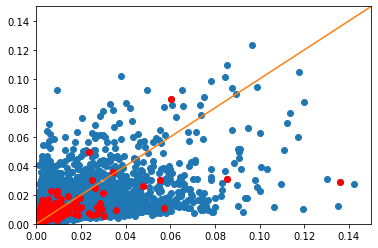

In [148]:
x = np.arange(0,0.2,0.01)
y =x

plt.plot(ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network"]["mean_importance"].values.tolist(), ranking[f"dynGENIE3_{degree}Degree_100Nodes_2network_rand"]["mean_importance"].values.tolist(), 'o')
plt.plot(ranking_real_data_frame["mean_importance"].values.tolist(), ranking_real_data_frame_rand["mean_importance"].values.tolist(), 'o',color = "r")
plt.plot(x,y)
plt.xlim(0,0.15)
plt.ylim(0,0.15)

In [144]:
ranking_real_data_frame["mean_importance"]

0          0.003627
1          0.000000
2          0.000000
3          0.000000
4          0.000000
             ...   
1979995    0.000000
1979996    0.000000
1979997    0.000000
1979998    0.000000
1979999    0.000000
Name: mean_importance, Length: 1980000, dtype: float64

In [149]:
ranking_real_data_frame_rand["mean_importance"]

0          0.011116
1          0.000000
2          0.000000
3          0.000000
4          0.000000
             ...   
1979995    0.000000
1979996    0.000000
1979997    0.000000
1979998    0.000000
1979999    0.000000
Name: mean_importance, Length: 1980000, dtype: float64

In [74]:
ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network"][ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network"]["regulator-target"] == "('G1', 'G2')"]

,regulator-target,mean_importance
1,"('G1', 'G2')",0.041677


In [75]:
ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network"][ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network"]["regulator-target"] == "('G2', 'G1')"]

,regulator-target,mean_importance
18,"('G2', 'G1')",0.101933


In [76]:
ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network_rand"][ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network_rand"]["regulator-target"] == "('G2', 'G1')"]

,regulator-target,mean_importance
18,"('G2', 'G1')",0.073723


In [77]:
ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network_rand"][ranking[f"dynGENIE3_{degree}Degree_10Nodes_2network_rand"]["regulator-target"] == "('G1', 'G2')"]

,regulator-target,mean_importance
1,"('G1', 'G2')",0.106756


In [150]:
ranking[f"SWING_{degree}Degree_{nodes}Nodes_{instance}network"]

,regulator-target,mean_importance
0,"('G1', 'G10')",0.000588
1,"('G1', 'G100')",0.001132
2,"('G1', 'G11')",0.003989
3,"('G1', 'G12')",0.000388
4,"('G1', 'G13')",0.006144
...,...,...
9895,"('G99', 'G94')",0.002041
9896,"('G99', 'G95')",0.003985
9897,"('G99', 'G96')",0.000777
9898,"('G99', 'G97')",0.000542


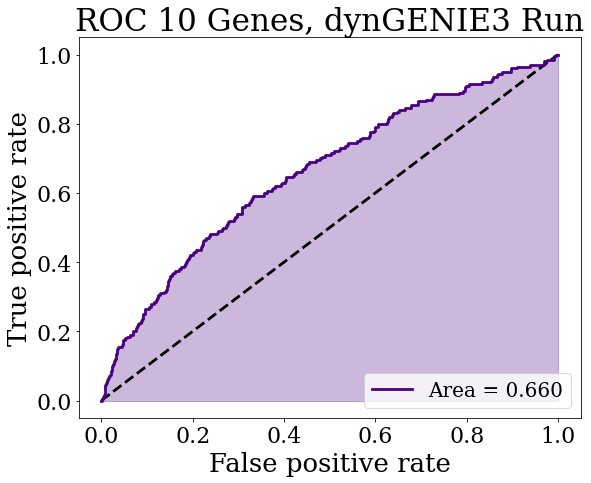

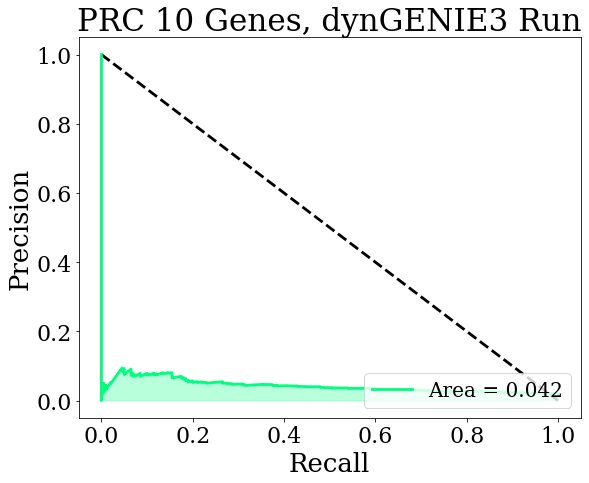

In [4]:
new_ranking = pd.DataFrame()
new_ranking_list = []
new_ranking_genes = []


        
for i in range(len(ranking[f"SWING_2Degree_100Nodes_1network"])):
    if (ranking[f"SWING_2Degree_100Nodes_1network_crand"]["mean_importance"].iloc[i] > ranking[f"SWING_2Degree_100Nodes_3network_rand"]["mean_importance"].iloc[i]) and (ranking[f"SWING_2Degree_100Nodes_3network_crand"]["mean_importance"].iloc[i] > ranking[f"SWING_2Degree_100Nodes_3network"]["mean_importance"].iloc[i]):
        
        new_ranking_list.append(ranking[f"SWING_2Degree_100Nodes_3network_crand"]["mean_importance"].iloc[i])
    
    elif (ranking[f"SWING_2Degree_100Nodes_3network_rand"]["mean_importance"].iloc[i] > ranking[f"SWING_2Degree_100Nodes_3network_crand"]["mean_importance"].iloc[i]) and (ranking[f"SWING_2Degree_100Nodes_3network_rand"]["mean_importance"].iloc[i] > ranking[f"SWING_2Degree_100Nodes_3network"]["mean_importance"].iloc[i]):
        
        new_ranking_list.append(ranking[f"SWING_2Degree_100Nodes_3network_rand"]["mean_importance"].iloc[i])
        
    else:
        new_ranking_list.append(ranking[f"SWING_2Degree_100Nodes_3network"]["mean_importance"].iloc[i])


new_ranking["regulator-target"] = new_ranking_genes    
new_ranking["mean_importance"] = new_ranking_list

gold_standard = pd.read_csv(f"networks_in_out_degree_2_num_nodes_100/Networks_in_out_degree_2_num_nodes_100/in_and_out_degree_2_num_nodes_100_case_3/goldstandard_signed_3_goldstandard.tsv", sep="\t", names= header_list).sort_values(by=["Cause Gene","Effect Gene"])
        
AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["mean_importance"], ranking[f"SWING_2Degree_100Nodes_3network_rand"]['mean_importance'], 10, "Nothing", f"dynGENIE3 Run", show_plot=True)


In [38]:
ranking[f"SWING_2Degree_100Nodes_5network_rand"]["mean_importance"].max()

0.0295736066268919

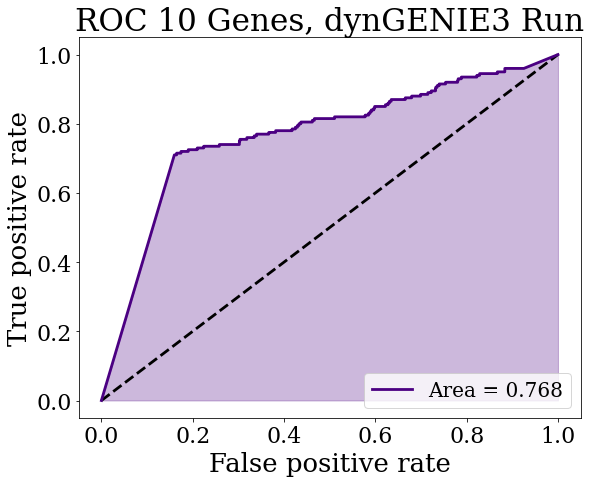

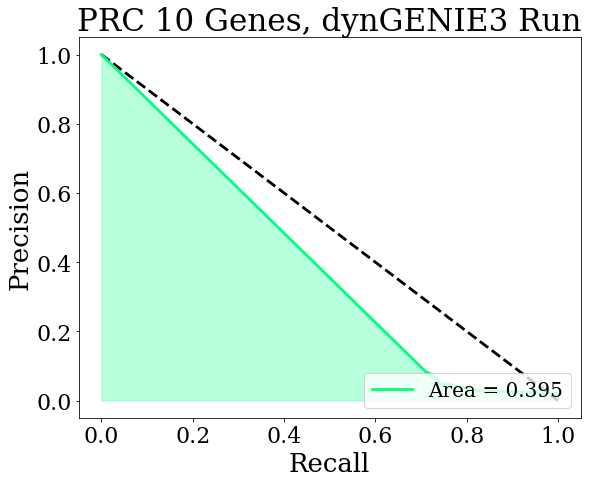

In [60]:
new_ranking = pd.DataFrame()
new_ranking_list = []
new_ranking_genes = []

for i in range(len(ranking[f"SWING_2Degree_100Nodes_6network"])):
    
    if ranking[f"SWING_2Degree_100Nodes_6network"]["mean_importance"].iloc[i] > ranking[f"SWING_2Degree_100Nodes_6network"]["mean_importance"].mean():
        
        if (ranking[f"SWING_2Degree_100Nodes_6network"]["mean_importance"].iloc[i]) > ranking[f"SWING_2Degree_100Nodes_6network_crand"]["mean_importance"].iloc[i]:
    
            new_ranking_list.append(1)
        else:
            new_ranking_list.append(0)
    else:
        new_ranking_list.append(ranking[f"SWING_2Degree_100Nodes_5network"]["mean_importance"].iloc[i])

        new_ranking["regulator-target"] = new_ranking_genes    
new_ranking["mean_importance"] = new_ranking_list

gold_standard = pd.read_csv(f"networks_in_out_degree_2_num_nodes_100/Networks_in_out_degree_2_num_nodes_100/in_and_out_degree_2_num_nodes_100_case_6/goldstandard_signed_6_goldstandard.tsv", sep="\t", names= header_list).sort_values(by=["Cause Gene","Effect Gene"])
        
AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["mean_importance"], new_ranking['mean_importance'], 10, "Nothing", f"dynGENIE3 Run", show_plot=True)


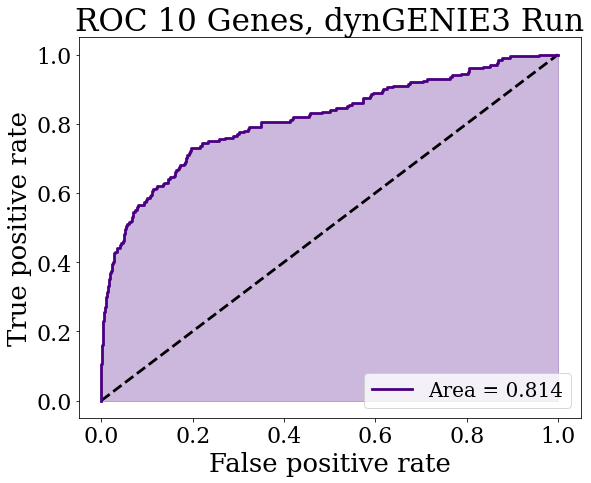

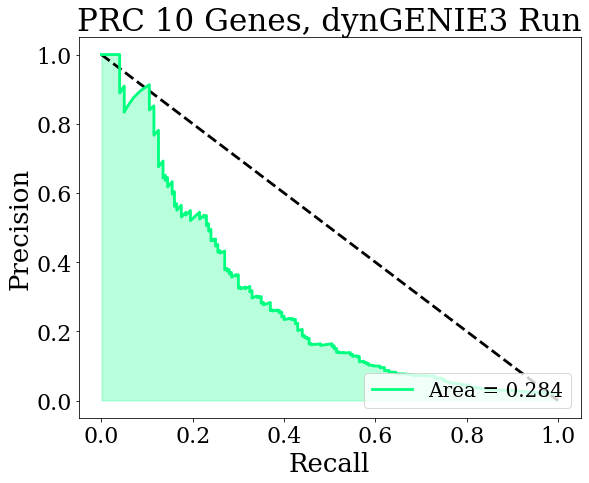

In [61]:
AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["mean_importance"], ranking[f"SWING_2Degree_100Nodes_6network"]["mean_importance"].values, 10, "Nothing", f"dynGENIE3 Run", show_plot=True)


In [8]:
ranking[f"SWING_2Degree_100Nodes_5network_rand"]

,regulator-target,mean_importance
0,"('G1', 'G10')",0.002081
1,"('G1', 'G100')",0.004601
2,"('G1', 'G11')",0.000967
3,"('G1', 'G12')",0.002576
4,"('G1', 'G13')",0.002389
...,...,...
9895,"('G99', 'G94')",0.001554
9896,"('G99', 'G95')",0.004483
9897,"('G99', 'G96')",0.001375
9898,"('G99', 'G97')",0.005456


In [51]:
new_ranking

,regulator-target,mean_importance
0,NaN,0.006257
1,NaN,0 0.003506 1 0.034297 2 0.00...
2,NaN,0.008696
3,NaN,0.005648
4,NaN,0.047519
...,...,...
9895,NaN,0.014628
9896,NaN,0 0.003506 1 0.034297 2 0.00...
9897,NaN,0.007347
9898,NaN,0.003539


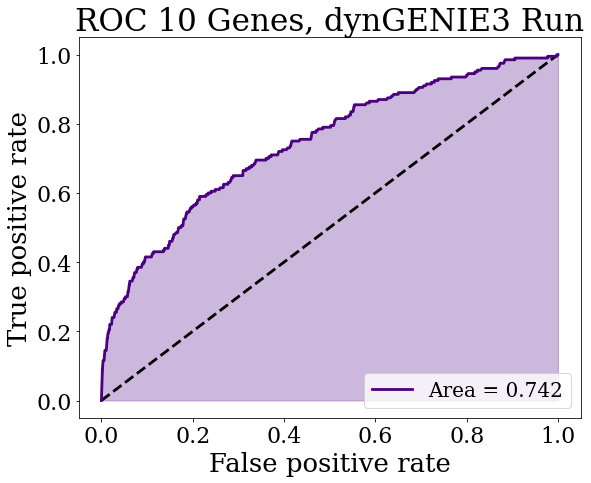

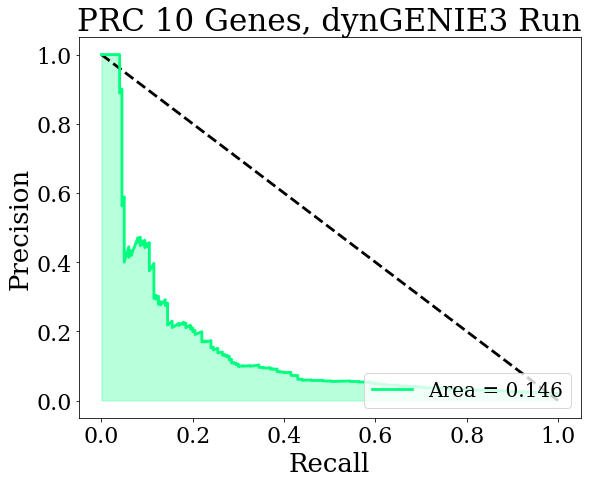

In [116]:
AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["mean_importance"], ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["mean_importance"], 10, "Nothing", f"dynGENIE3 Run", show_plot=True)


# Filtering the interactions

In [133]:
#G1 > G2
#G2 > G3
ranking[f"dynGENIE3_2Degree_100Nodes_5network"][(ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Cause Gene"] == "G1") & (ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Effect Gene"] == "G2")]

,Cause Gene,Effect Gene,mean_importance
11,G1,G2,0.008009


In [135]:
list_genes[-3]

'G98'

In [157]:
len(ranking[f"dynGENIE3_2Degree_100Nodes_5network"])

9900

In [169]:
list_genes = [f"G{i+1}" for i in range(100)]
new_ranking_list = pd.DataFrame(columns = ["regulator-target", "mean_importance"])

iterador = 0
for i in range(100):
    
    for j in range(100):
        print(iterador)
        if i != j:
            
            number1 = ranking[f"dynGENIE3_2Degree_100Nodes_5network"][(ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Cause Gene"] == list_genes[i-3]) & (ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Effect Gene"] == list_genes[j-2])]["mean_importance"].values
            number2 = ranking[f"dynGENIE3_2Degree_100Nodes_5network"][(ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Cause Gene"] == list_genes[j-2]) & (ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Effect Gene"] == list_genes[j-1])]["mean_importance"].values
            number3 = ranking[f"dynGENIE3_2Degree_100Nodes_5network"][(ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Cause Gene"] == list_genes[i-3]) & (ranking[f"dynGENIE3_2Degree_100Nodes_5network"]["Effect Gene"] == list_genes[j-1])]["mean_importance"].values
            
            if (number1 > number3) & (number2 > number3):
                
                new_ranking_list.loc[iterador] = [f"({list_genes[i-3]},{list_genes[j-2]})", number1[0]]
                new_ranking_list.loc[iterador] = [f"({list_genes[j-2]},{list_genes[j-1]})", number2[0]]
                
            else:
                new_ranking_list.loc[iterador] = [f"({list_genes[i-3]},{list_genes[j-1]})", 0]
                
            iterador = iterador +1

C:\Users\ivana\AppData\Local\Temp/ipykernel_9336/1601138096.py:15: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if (number1 > number3) & (number2 > number3):


In [172]:
new_ranking_list[0:20]#.sort_values(by = ["regulator-target"])

,regulator-target,mean_importance
0,"(G100,G1)",0.003742
1,"(G98,G2)",0.000000
2,"(G2,G3)",0.003313
3,"(G98,G4)",0.000000
4,"(G98,G5)",0.000000
5,"(G98,G6)",0.000000
6,"(G98,G7)",0.000000
7,"(G98,G8)",0.000000
8,"(G98,G9)",0.000000
9,"(G98,G10)",0.000000


In [167]:
gold_standard

,Cause Gene,Effect Gene,mean_importance
223,G1,G10,0
256,G1,G100,0
207,G1,G11,0
228,G1,G12,0
231,G1,G13,0
...,...,...,...
7931,G99,G94,0
7927,G99,G95,0
7928,G99,G96,0
7943,G99,G97,0


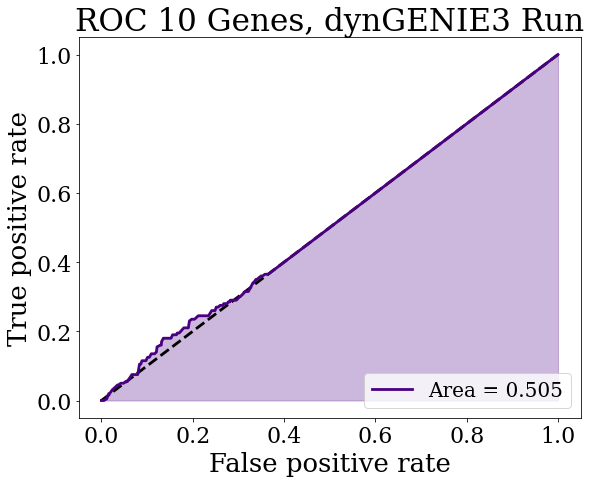

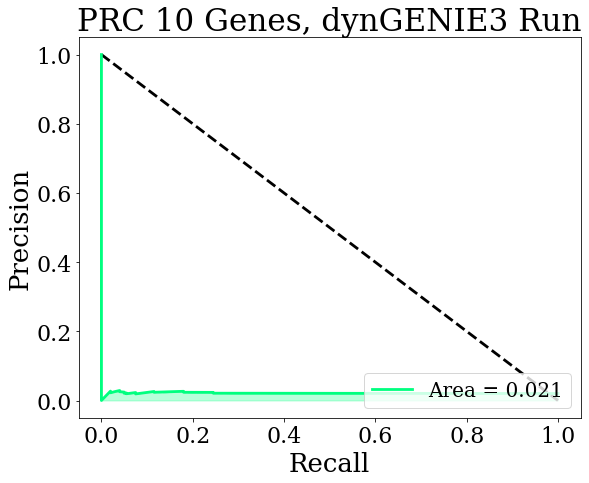

In [156]:
gold_standard = pd.read_csv(f"networks_in_out_degree_2_num_nodes_100/Networks_in_out_degree_2_num_nodes_100/in_and_out_degree_2_num_nodes_100_case_5/goldstandard_signed_5_goldstandard.tsv", sep="\t", names= header_list).sort_values(by=["Cause Gene","Effect Gene"])
        
AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["mean_importance"], new_ranking_list, 10, "Nothing", f"dynGENIE3 Run", show_plot=True)
